<h4>                                                                                    STUDY OF THE DATASET

In [101]:
#importiamo le librerie di base
import numpy as np 
import pandas as pd 
import librosa.display  # questa sereve per la rappresentazione grafica e gestione di file audio
import matplotlib.pyplot as plt  # serve per calcoli matematic 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import librosa, IPython

In [ ]:
#importiamo il dataset
music_data_30sec = pd.read_csv('Data/features_30_sec.csv') 
music_data_3sec = pd.read_csv('Data/features_3_sec.csv') 

music_data_30sec.head(400) #per vedere le prime 5 righe del dataset


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,disco.00095.wav,661504,0.467937,0.088231,0.098458,0.002791,2486.676086,573334.894350,2275.557079,174884.957794,...,77.314751,0.340131,115.327896,7.006258,119.066612,-5.464714,96.617668,0.794422,80.472687,disco
396,disco.00096.wav,661504,0.416615,0.082022,0.092015,0.001672,2481.466513,369996.183245,2178.434932,69515.883904,...,65.386269,2.098823,59.525497,5.433709,51.197662,3.084094,68.519188,2.458709,57.174606,disco
397,disco.00097.wav,661504,0.414973,0.084070,0.108184,0.002241,2825.891195,315358.182805,2680.155772,68180.463802,...,36.301414,-6.221204,41.428925,8.014792,62.738834,-8.036930,39.482159,4.391325,43.750019,disco
398,disco.00098.wav,661504,0.440995,0.082474,0.122678,0.001555,2417.757363,353068.894106,2431.888669,82783.692734,...,49.107792,-10.156887,40.113514,4.787725,45.301830,-6.897258,47.557076,-0.993489,41.193317,disco


In [ ]:
audio_fp = 'Data/genres_original/blues/blues.00000.wav'
audio_data, sr = librosa.load(audio_fp)
audio_data, _ = librosa.effects.trim(audio_data)
IPython.display.Audio(audio_data, rate=sr)


<h3> Studio dei generi musicali 

In [ ]:
print("Dataset has",music_data_30sec.shape)
print("Count of Positive and Negative samples")
music_data_30sec.label.value_counts().reset_index()


Dataset has (1000, 60)
Count of Positive and Negative samples


,label,count
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100


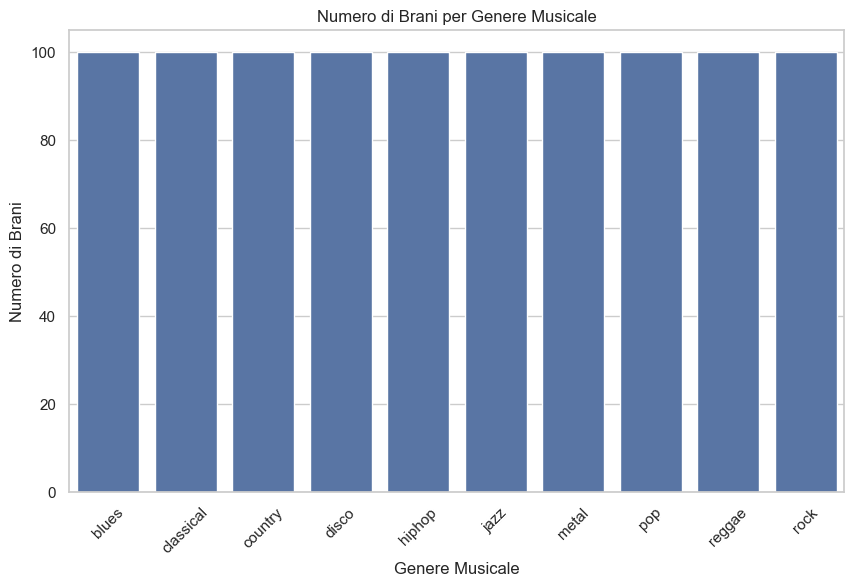

In [ ]:
# Contare le occorrenze di ciascun genere e salvarlo in genre_counts

genre_counts = music_data_30sec['label'].value_counts()

# Plot del numero dei tipi musicali
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xlabel("Genere Musicale")
plt.ylabel("Numero di Brani")
plt.title("Numero di Brani per Genere Musicale")
plt.xticks(rotation=45)  # Ruota le etichette per una migliore leggibilità
plt.show()


In [ ]:
print("Dataset has",music_data_3sec.shape)
print("Count of Positive and Negative samples")
music_data_3sec.label.value_counts().reset_index()


Dataset has (9990, 60)
Count of Positive and Negative samples


,label,count
0,blues,1000
1,jazz,1000
2,metal,1000
3,pop,1000
4,reggae,1000
5,disco,999
6,classical,998
7,hiphop,998
8,rock,998
9,country,997


<h3> Esempio stampa file wav

blues


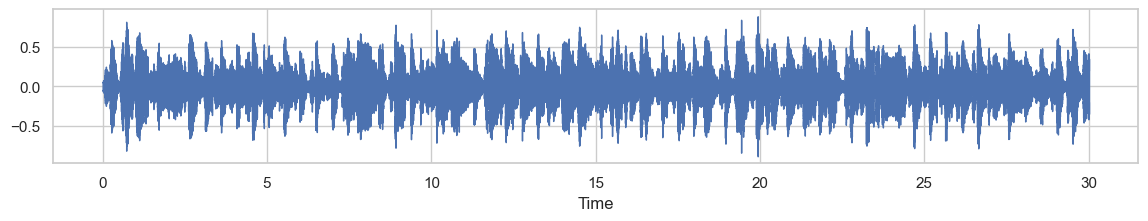

In [77]:
#Stampo la struttura del file audio medio del genere BLUES
path = 'Data/genres_original/blues/blues.00000.wav' 
plt.figure(figsize=(14, 2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr) 

print("blues")  
  

Pop


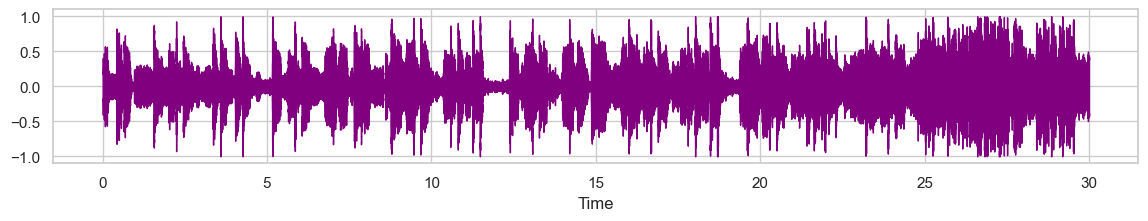

In [ ]:
path = 'Data/genres_original/pop/pop.00000.wav'
plt.figure(figsize=(14,2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr,color='purple')  
print("Pop")


Metal


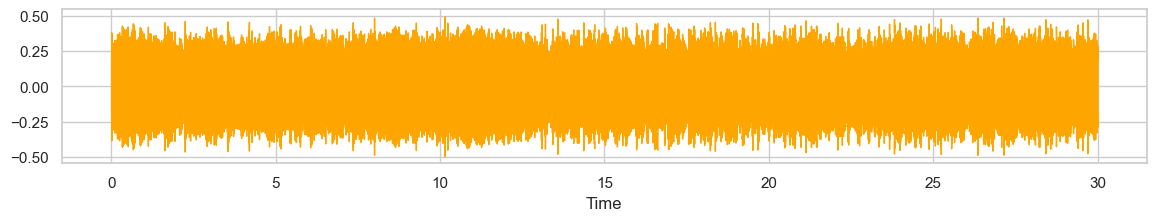

In [ ]:
path = 'Data/genres_original/metal/metal.00000.wav'
plt.figure(figsize=(14, 2)) 
x, sr = librosa.load(path) 
librosa.display.waveshow(x, sr=sr,color='orange') 
print("Metal")


C:\Users\romeo\AppData\Local\Temp\ipykernel_996\2920817855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');


Text(0, 0.5, 'BPM')

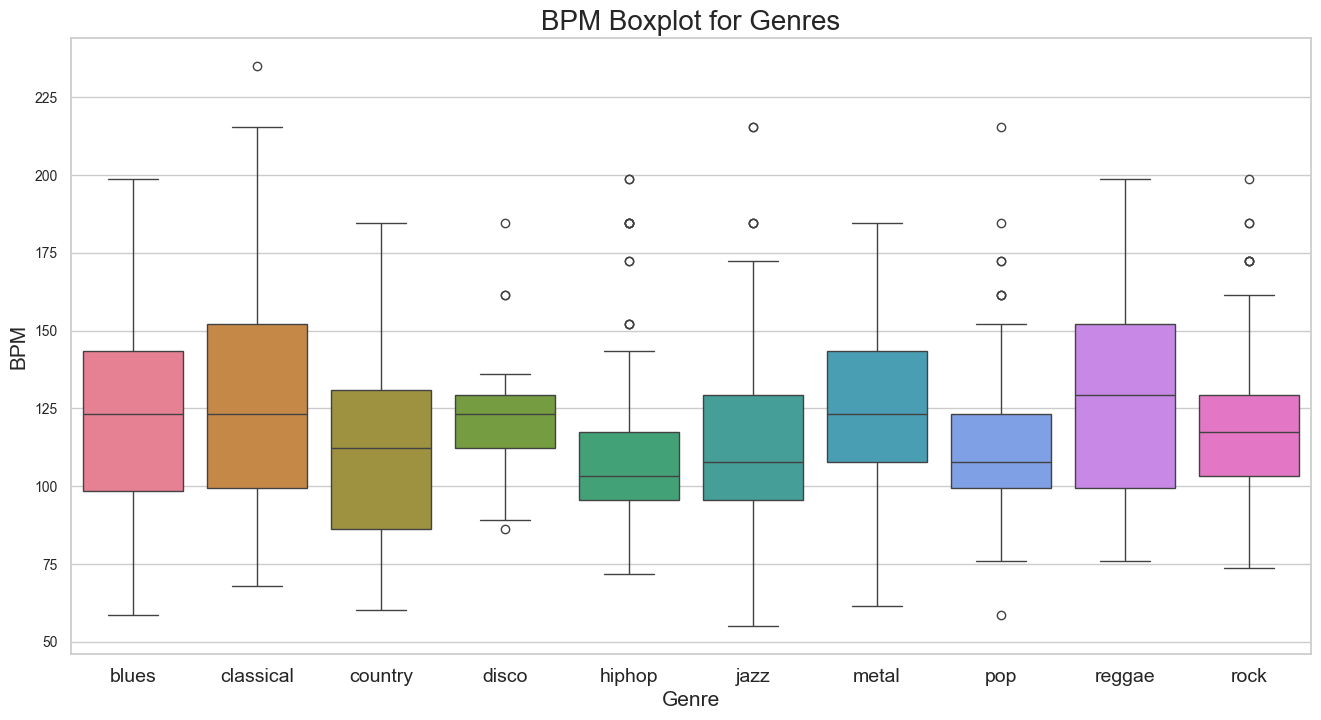

In [113]:
x = music_data_30sec[["label", "tempo"]]

fig, ax = plt.subplots(figsize=(16, 8));
sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');

plt.title('BPM Boxplot for Genres', fontsize = 20)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Genre", fontsize = 15)
plt.ylabel("BPM", fontsize = 15)


<h4> MATRICE DI CORRELAZIONE

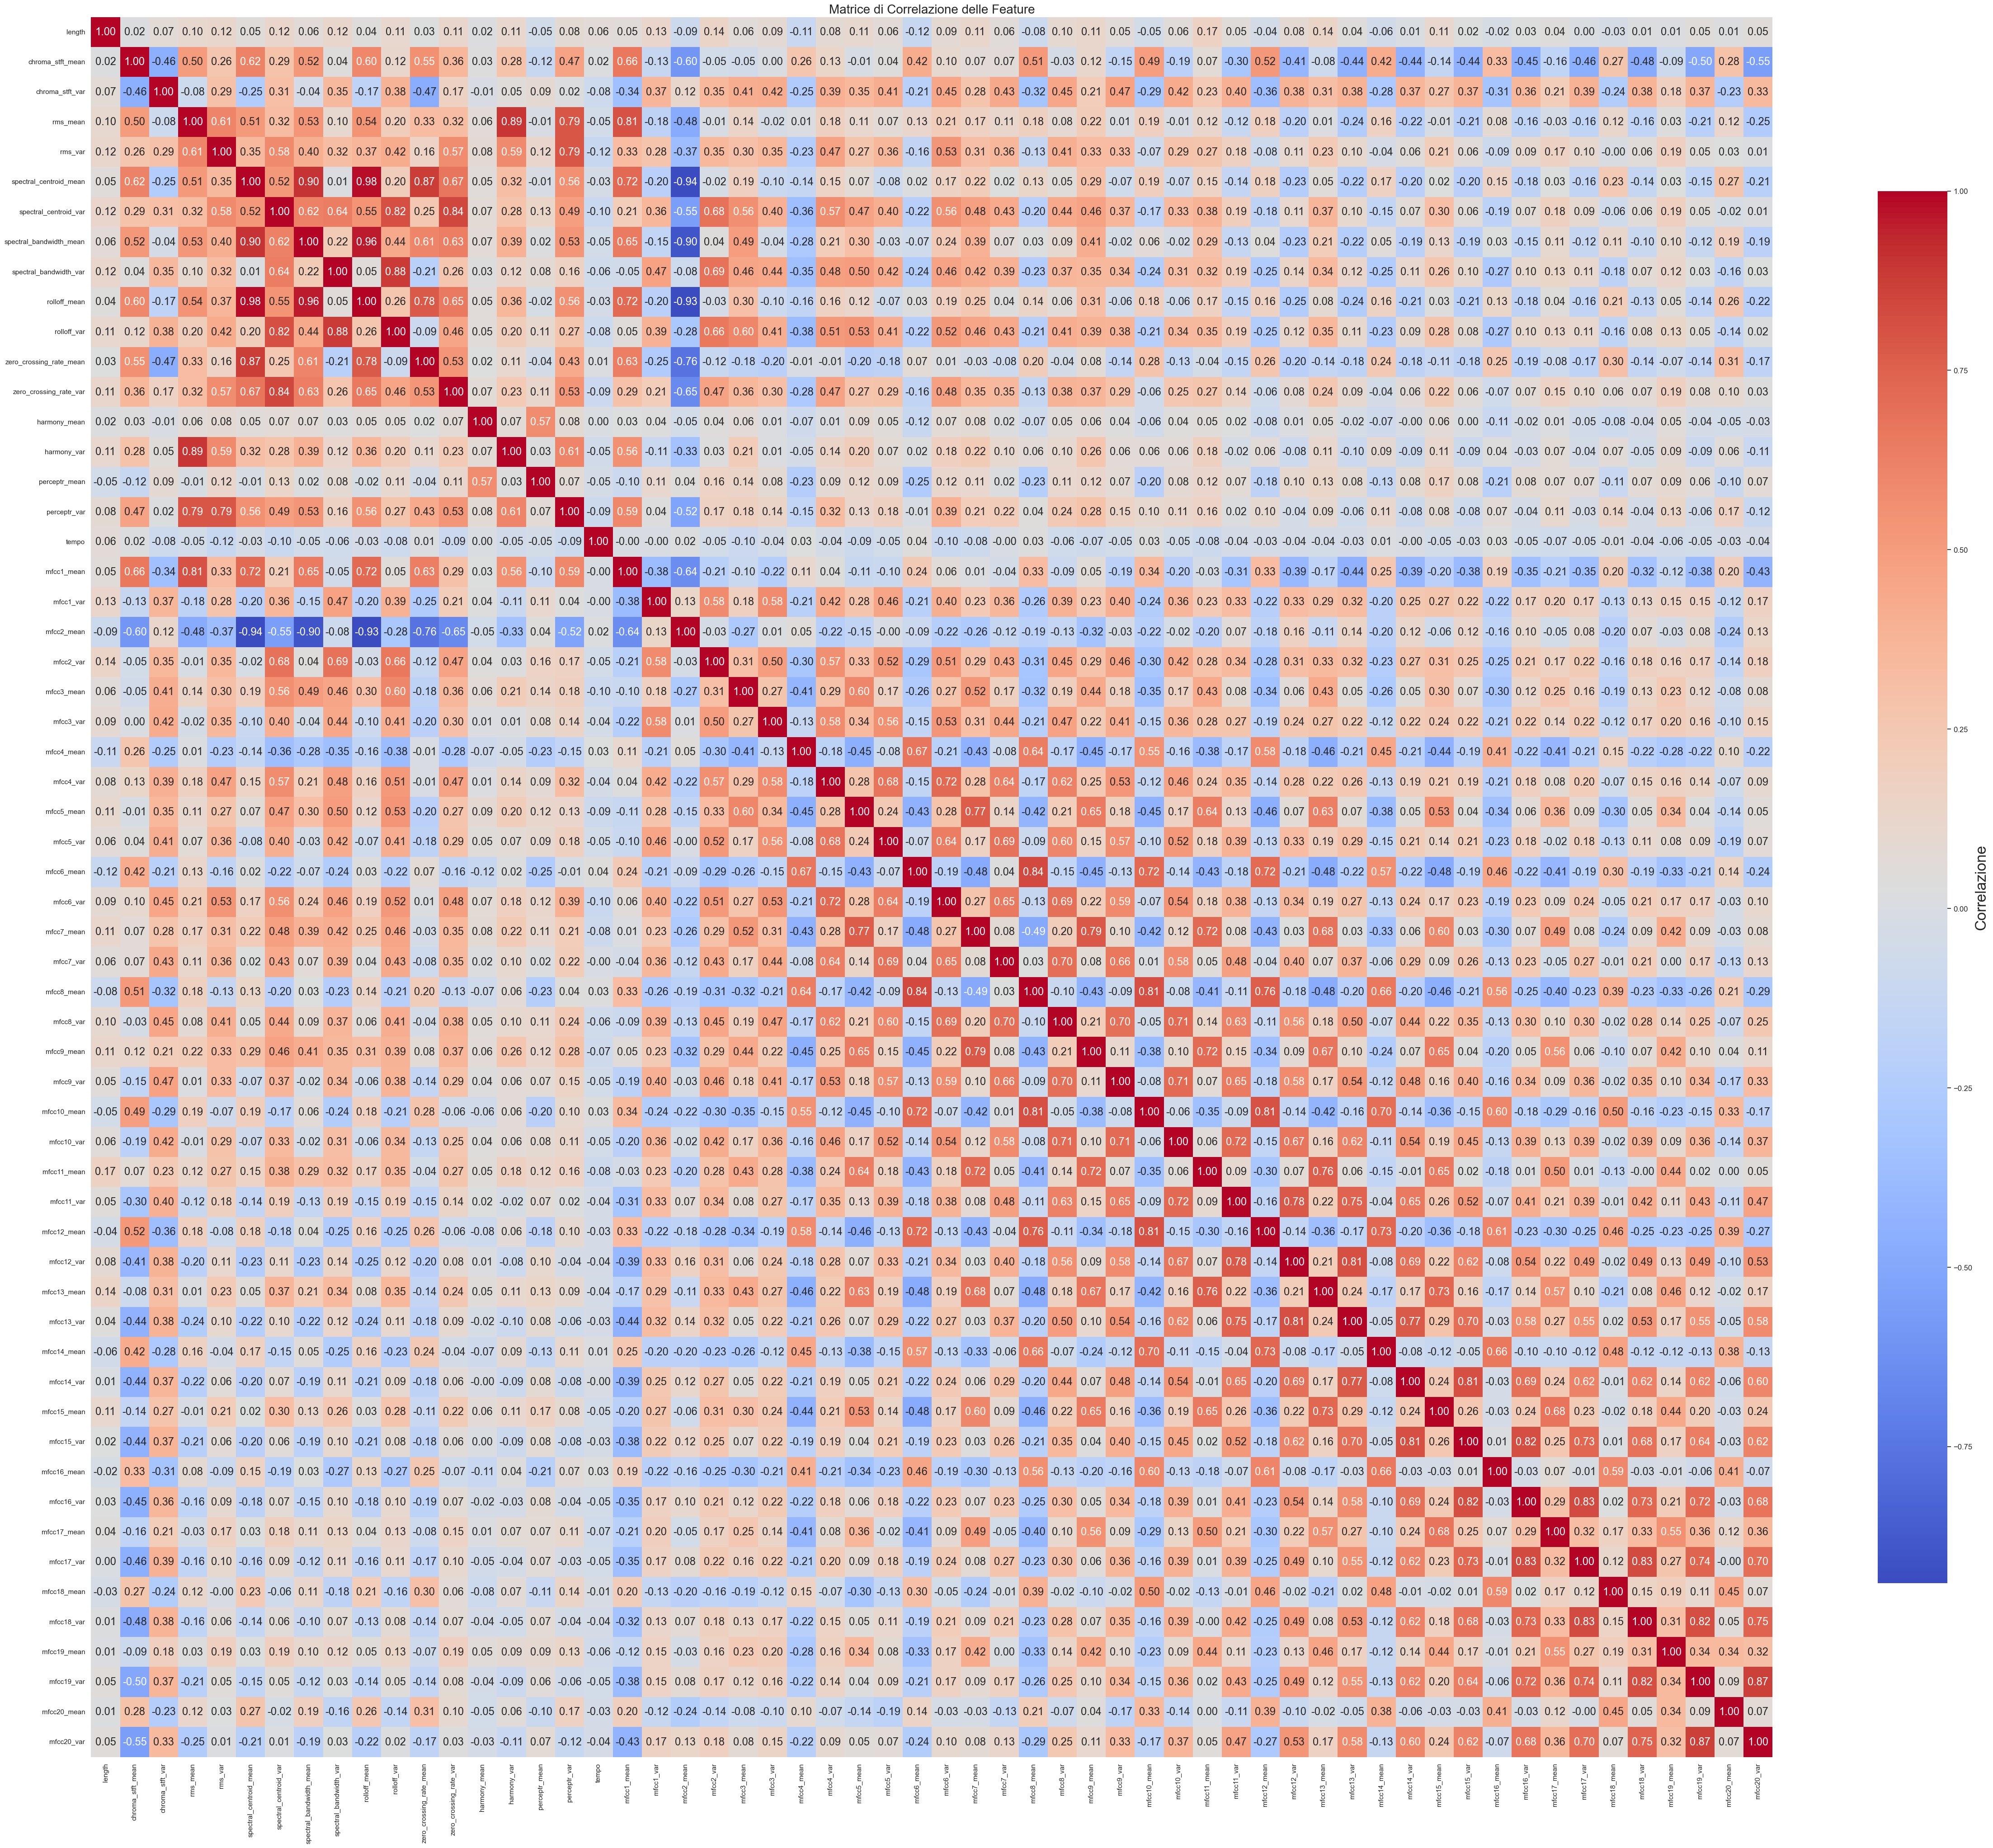

In [ ]:
# Rimuovo le colonne non numeriche

X = music_data_30sec.drop(columns=['label', 'filename'])

# Calcola la matrice di correlazione
correlation_matrix = X.corr()

# Configura la dimensione della heatmap
plt.figure(figsize=(60, 50))

# Crea la heatmap
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
                       xticklabels=X.columns, yticklabels=X.columns,
                       annot_kws={"size": 17},  # Aumenta la dimensione del font per i valori
                       cbar_kws={"shrink": 0.8, "label": "Correlazione"})  # Rimuovi fontsize da qui


plt.title('Matrice di Correlazione delle Feature', fontsize=20)  # Aumenta la dimensione del titolo
colorbar = heatmap.collections[0].colorbar  # Ottieni il colorbar dalla heatmap
colorbar.ax.tick_params(labelsize=12)  # Aumenta la dimensione del font dei ticks
colorbar.set_label("Correlazione", fontsize=24)  # Imposta il font della label del colorbar
plt.show()


<h3> GRAFICO LUNGHEZZA BRANO 30

label
blues        661794.00
classical    662116.10
country      662027.76
disco        661934.80
hiphop       663468.24
jazz         662233.28
metal        661596.80
pop          661504.00
reggae       661622.90
rock         662010.58
Name: length, dtype: float64


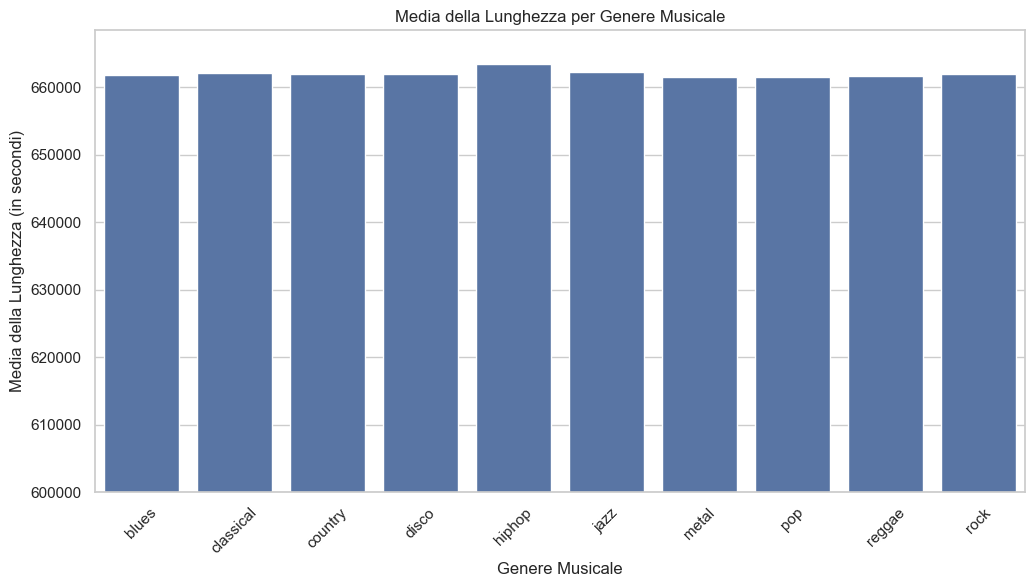

In [ ]:
mean_length_by_genre = music_data_30sec.groupby('label')['length'].mean()

print(music_data_30sec.groupby('label')['length'].mean())

# Visualizzo la media della lunghezza per ogni genere musicale
plt.figure(figsize=(12, 6))
sns.barplot(x=mean_length_by_genre.index, y=mean_length_by_genre.values)
plt.xlabel("Genere Musicale")
plt.ylabel("Media della Lunghezza (in secondi)")
plt.title("Media della Lunghezza per Genere Musicale")
plt.xticks(rotation=45)  # Ruota le etichette per una migliore leggibilità
plt.ylim(600000, mean_length_by_genre.max() + 5000)  # Imposta l'asse y da 500000

plt.show()

<H3>VARIANZA SPIEGATA 30 SECONDI

   Principal Component Most Influential Feature  Explained Variance Ratio
0                  PC1                mfcc2_var                  0.235683
1                  PC2             rolloff_mean                  0.166545
2                  PC3              mfcc10_mean                  0.105655
3                  PC4              mfcc17_mean                  0.074709
4                  PC5              mfcc16_mean                  0.045014
5                  PC6              harmony_var                  0.033777
6                  PC7             harmony_mean                  0.029439
7                  PC8            perceptr_mean                  0.025616
8                  PC9             harmony_mean                  0.023732
9                 PC10                   length                  0.019634
10                PC11                    tempo                  0.017729
11                PC12                    tempo                  0.016020
12                PC13                

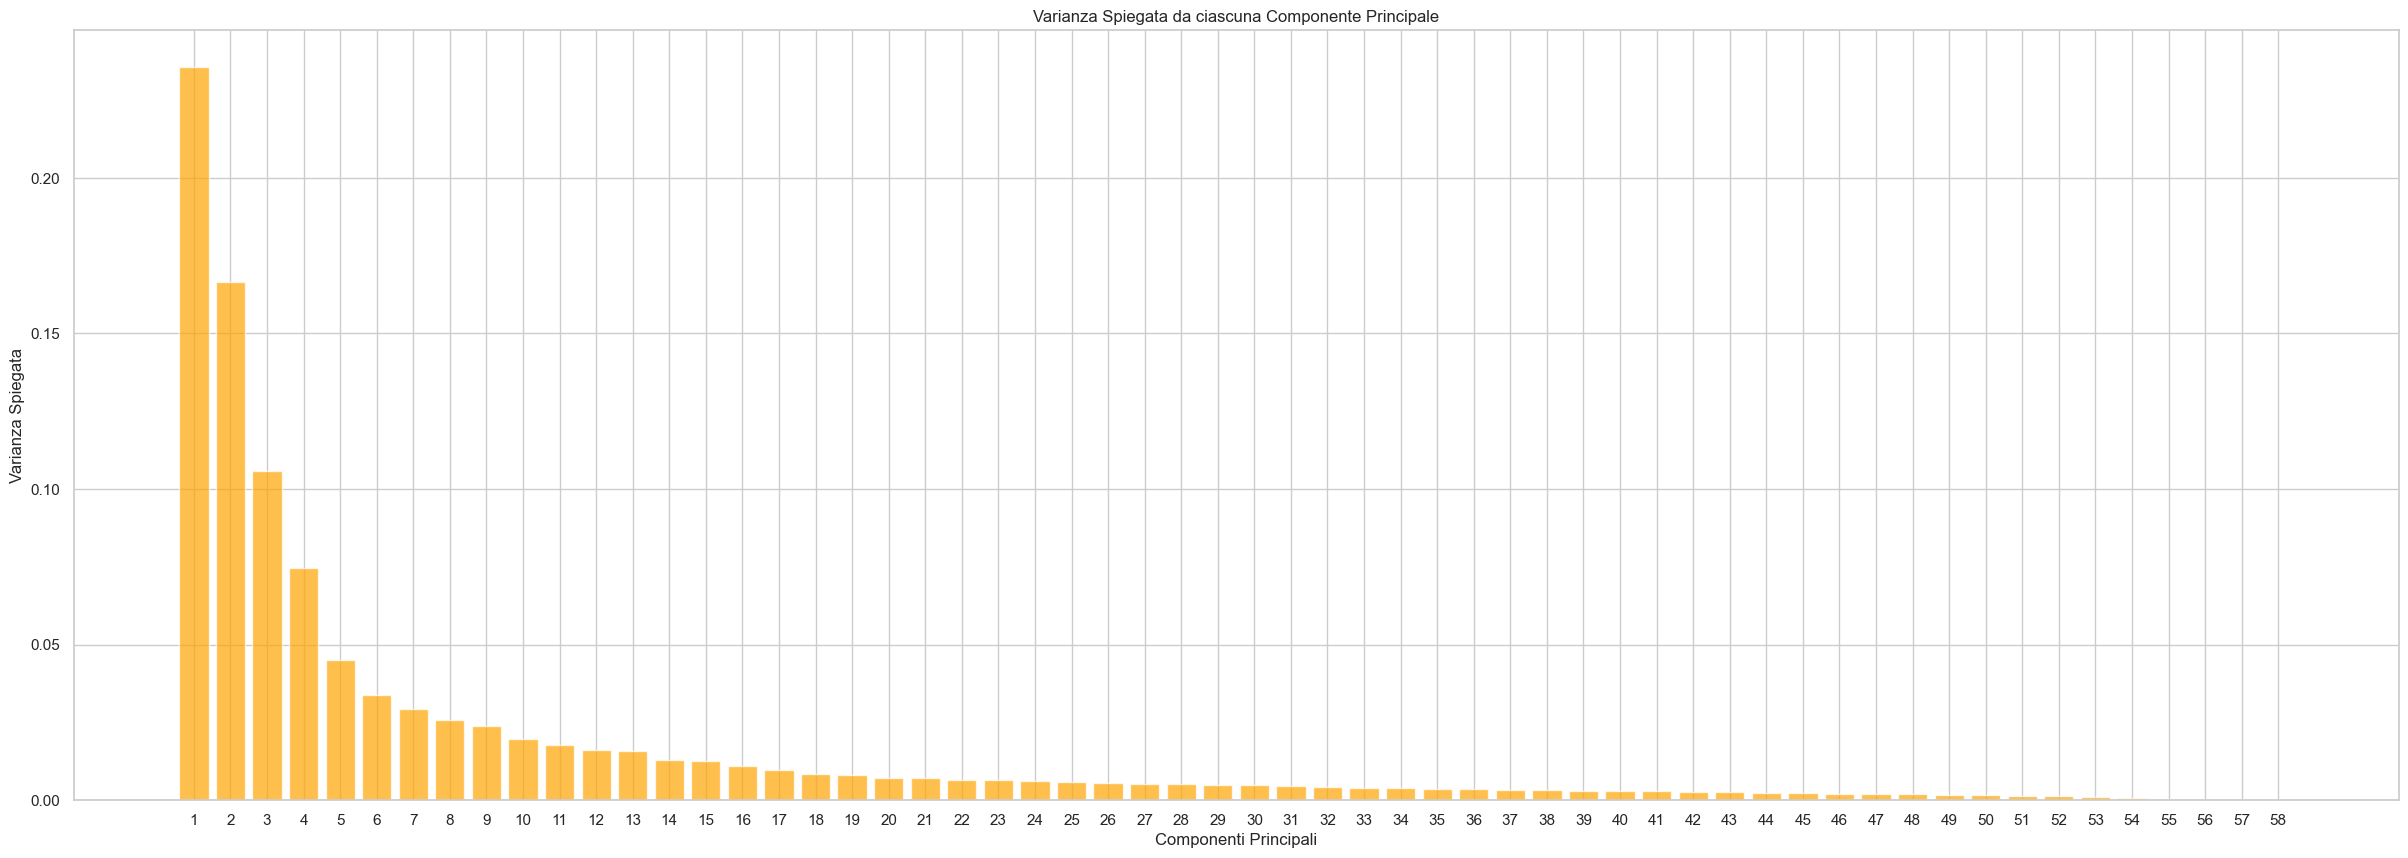

In [ ]:
# Rimuovo le colonne non numeriche
X = music_data_30sec.drop(columns=['label', 'filename'])
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizzo i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applico PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifico le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trovo la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combino i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})

print(pc_summary)

# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()

<H3> VARIANZA SPIEGATA 3 SECONDI

   Principal Component Most Influential Feature  Explained Variance Ratio
0                  PC1    spectral_centroid_var                  0.200550
1                  PC2               mfcc1_mean                  0.135427
2                  PC3              mfcc10_mean                  0.103453
3                  PC4               mfcc19_var                  0.065943
4                  PC5              mfcc16_mean                  0.043561
5                  PC6              harmony_var                  0.036772
6                  PC7               mfcc18_var                  0.029538
7                  PC8            perceptr_mean                  0.026538
8                  PC9             harmony_mean                  0.024887
9                 PC10              mfcc20_mean                  0.021422
10                PC11                    tempo                  0.018583
11                PC12                    tempo                  0.017399
12                PC13                

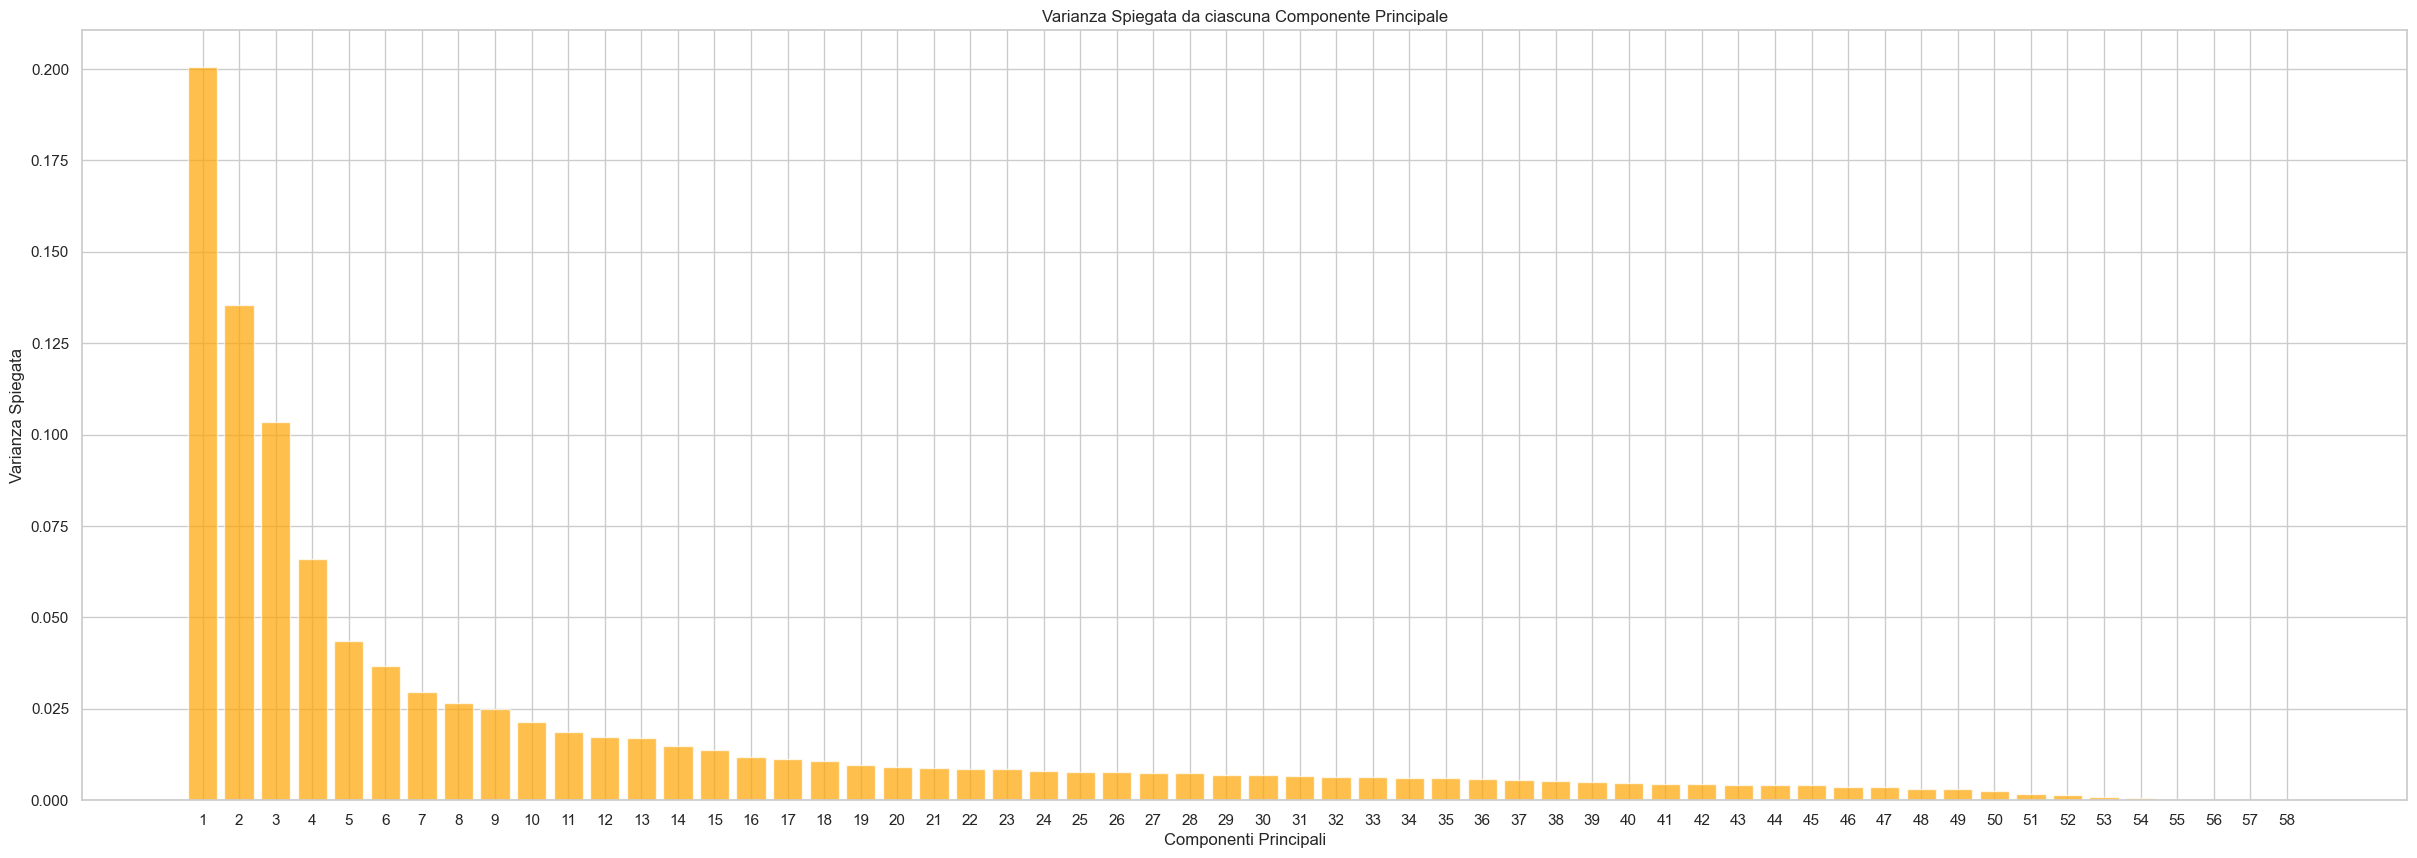

In [115]:
# Rimuovi le colonne non numeriche
X = music_data_3sec.drop(columns=['label', 'filename'])
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applica PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifica le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trova la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combina i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})

print(pc_summary)

# HO 58 COMPONENTI PERCHE' NE SONO STATE TOLTE 2: FILE NAME E LABEL 

# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()




Text(0, 0.5, 'Principal Component 2')

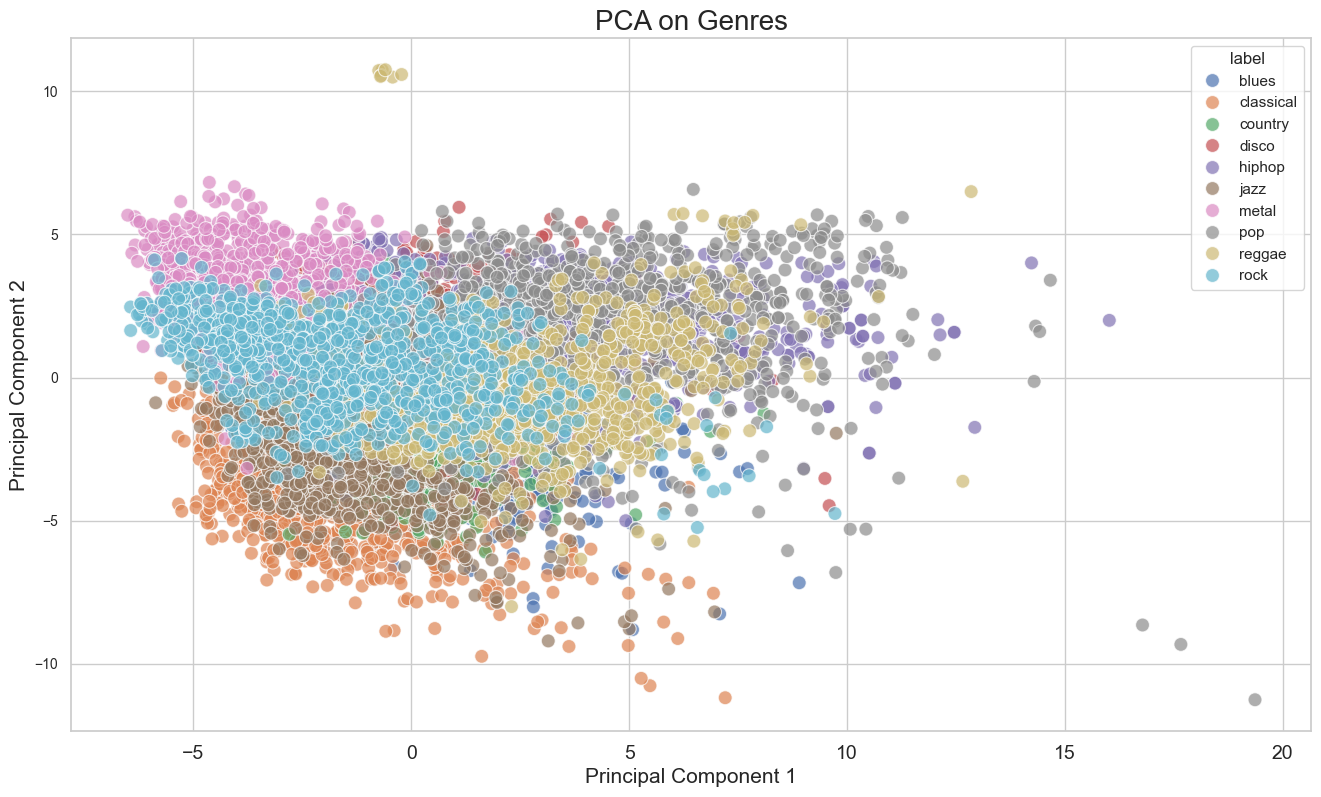

In [116]:
data = music_data_3sec.iloc[0:, 1:]
y = data['label']
X = data.loc[:, data.columns != 'label']

# normalize
cols = X.columns
# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns = cols)

# Top 2 pca components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])

# concatenate with target label
finalDf = pd.concat([principalDf, y], axis = 1)

plt.figure(figsize = (16, 9))
sns.scatterplot(x = "pc1", y = "pc2", data = finalDf, hue = "label", alpha = 0.7, s = 100);

plt.title('PCA on Genres', fontsize = 20)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
